# Phase 3: Model Evaluation & Comparison

This notebook compares all trained models side-by-side on the validation set,
performs error analysis, and selects the final model for API deployment.

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

MODELS_DIR = Path('../models')

## 1. Load All Results

In [2]:
# Traditional models + SBERT
trad_results = pd.read_csv(MODELS_DIR / 'traditional_results.csv')

# Transformer results
with open(MODELS_DIR / 'transformer_results.json') as f:
    transformer = json.load(f)

transformer_row = {
    'model': transformer['model'],
    'accuracy': transformer['accuracy'],
    'precision': transformer['precision'],
    'recall': transformer['recall'],
    'f1': transformer['f1'],
    'roc_auc': transformer['roc_auc'],
    'train_time_sec': transformer['train_time_sec'],
    'inference_time_sec': transformer['inference_time_sec'],
    'model_size_mb': transformer['model_size_mb'],
}

# Combine all results
all_results = pd.concat([trad_results, pd.DataFrame([transformer_row])], ignore_index=True)
all_results = all_results.sort_values('f1', ascending=False).reset_index(drop=True)

print(f'Total models compared: {len(all_results)}')
all_results

Total models compared: 8


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,inference_time_sec,model_size_mb
0,distilbert,0.9186,0.916435,0.9212,0.918811,0.975444,2910.33,38.8515,256.10
1,svm,0.9172,0.911278,0.9244,0.917792,0.973140,3.51,0.0166,1.91
2,ridge,0.9168,0.910236,0.9248,0.917460,0.972687,5.22,0.0184,1.91
3,logistic_regression,0.9066,0.896296,0.9196,0.907799,0.970259,1.32,0.0035,0.38
4,lightgbm,0.8964,0.889851,0.9048,0.897263,0.962769,190.71,0.1446,2.82
5,naive_bayes,0.8830,0.873004,0.8964,0.884547,0.952796,0.07,0.0104,1.53
6,random_forest,0.8658,0.859898,0.8740,0.866891,0.939640,96.15,0.3201,197.09
7,sbert_logreg,0.8334,0.834068,0.8324,0.833233,0.911944,2157.00,243.0723,0.00


## 2. Model Comparison Table

In [3]:
# Format for display
display_df = all_results.copy()
display_df['accuracy'] = display_df['accuracy'].map('{:.4f}'.format)
display_df['precision'] = display_df['precision'].map('{:.4f}'.format)
display_df['recall'] = display_df['recall'].map('{:.4f}'.format)
display_df['f1'] = display_df['f1'].map('{:.4f}'.format)
display_df['roc_auc'] = display_df['roc_auc'].map('{:.4f}'.format)
display_df['train_time_sec'] = display_df['train_time_sec'].map('{:.1f}'.format)
display_df['inference_time_sec'] = display_df['inference_time_sec'].map('{:.4f}'.format)
display_df['model_size_mb'] = display_df['model_size_mb'].map('{:.1f}'.format)

display_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC',
                       'Train Time (s)', 'Inference Time (s)', 'Size (MB)']

print('All Models — Validation Set Performance (sorted by F1):')
print('=' * 100)
display_df

All Models — Validation Set Performance (sorted by F1):


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s),Inference Time (s),Size (MB)
0,distilbert,0.9186,0.9164,0.9212,0.9188,0.9754,2910.3,38.8515,256.1
1,svm,0.9172,0.9113,0.9244,0.9178,0.9731,3.5,0.0166,1.9
2,ridge,0.9168,0.9102,0.9248,0.9175,0.9727,5.2,0.0184,1.9
3,logistic_regression,0.9066,0.8963,0.9196,0.9078,0.9703,1.3,0.0035,0.4
4,lightgbm,0.8964,0.8899,0.9048,0.8973,0.9628,190.7,0.1446,2.8
5,naive_bayes,0.8830,0.8730,0.8964,0.8845,0.9528,0.1,0.0104,1.5
6,random_forest,0.8658,0.8599,0.8740,0.8669,0.9396,96.2,0.3201,197.1
7,sbert_logreg,0.8334,0.8341,0.8324,0.8332,0.9119,2157.0,243.0723,0.0


## 3. Performance Visualizations

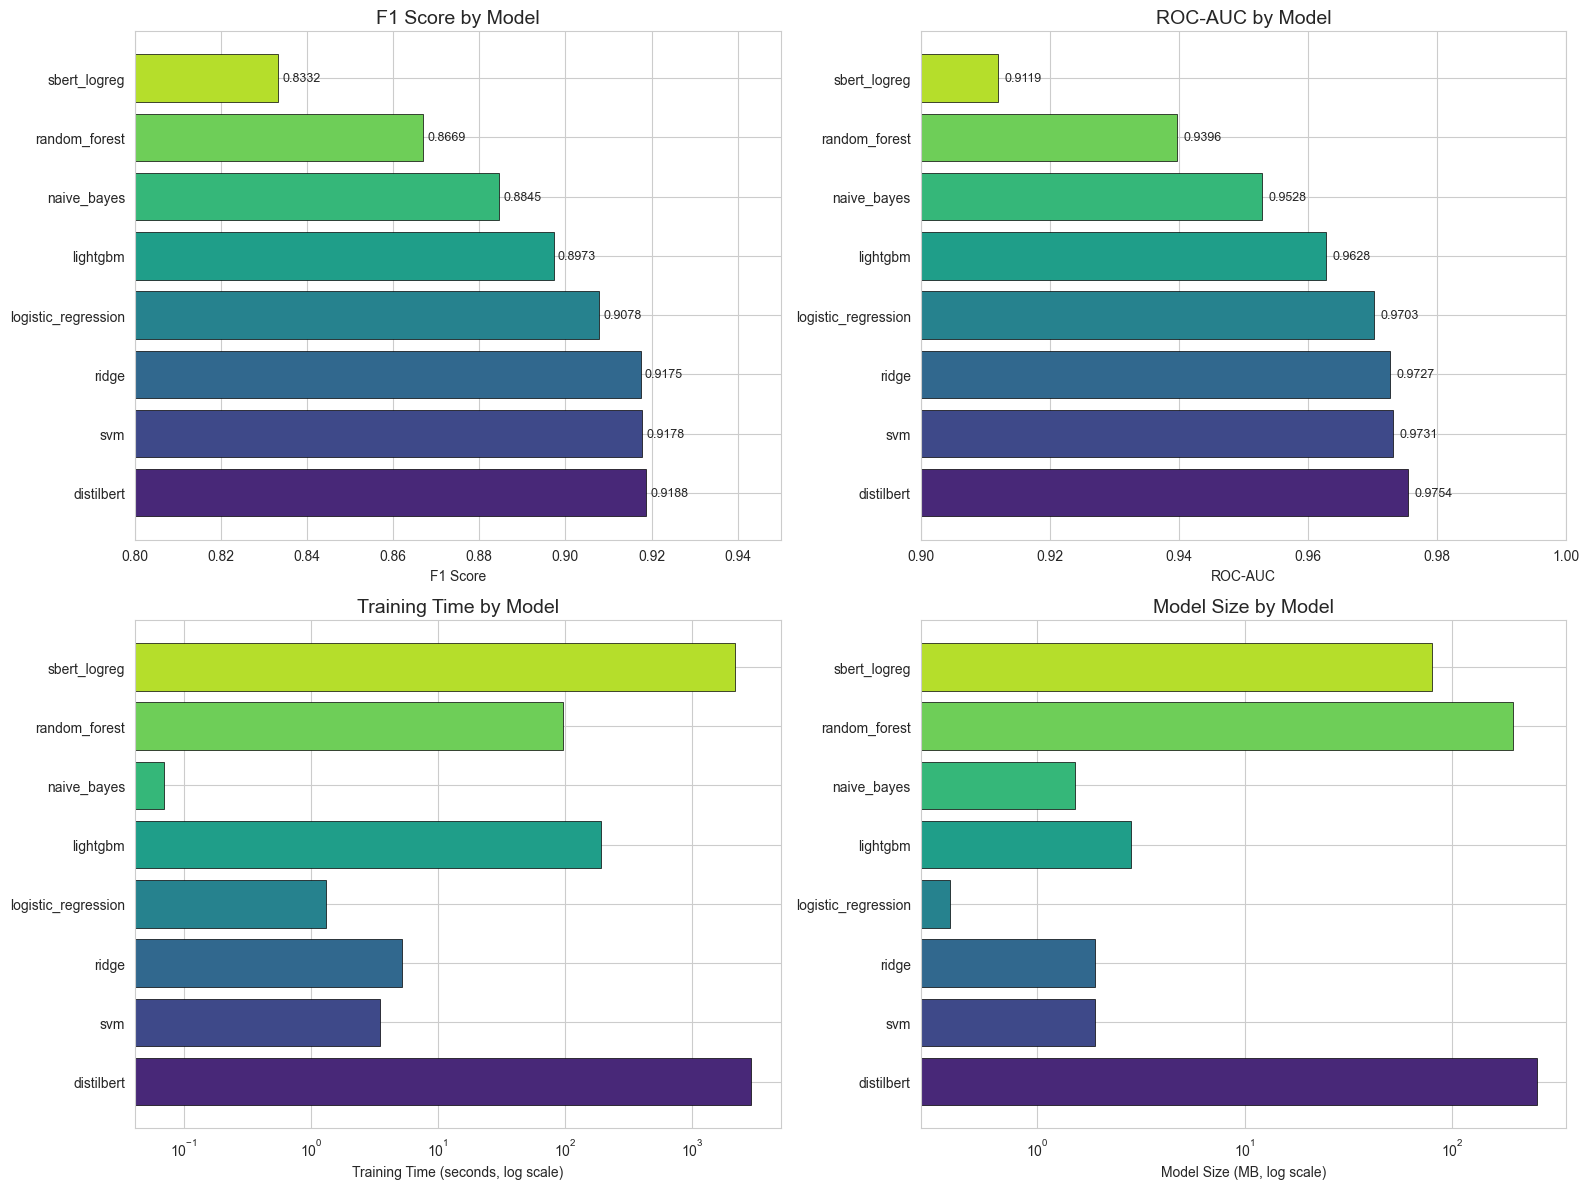

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
models = all_results['model'].tolist()
colors = sns.color_palette('viridis', len(models))

# F1 Score comparison
axes[0, 0].barh(models, all_results['f1'], color=colors, edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].set_title('F1 Score by Model', fontsize=14)
axes[0, 0].set_xlim(0.8, 0.95)
for i, v in enumerate(all_results['f1']):
    axes[0, 0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# ROC-AUC comparison
axes[0, 1].barh(models, all_results['roc_auc'], color=colors, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('ROC-AUC')
axes[0, 1].set_title('ROC-AUC by Model', fontsize=14)
axes[0, 1].set_xlim(0.9, 1.0)
for i, v in enumerate(all_results['roc_auc']):
    axes[0, 1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# Training time (log scale)
axes[1, 0].barh(models, all_results['train_time_sec'], color=colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('Training Time (seconds, log scale)')
axes[1, 0].set_title('Training Time by Model', fontsize=14)
axes[1, 0].set_xscale('log')

# Model size (log scale)
sizes = all_results['model_size_mb'].replace(0, 80)  # SBERT classifier is tiny, but encoder is ~80MB
axes[1, 1].barh(models, sizes, color=colors, edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Model Size (MB, log scale)')
axes[1, 1].set_title('Model Size by Model', fontsize=14)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

## 4. Accuracy vs. Efficiency Trade-off

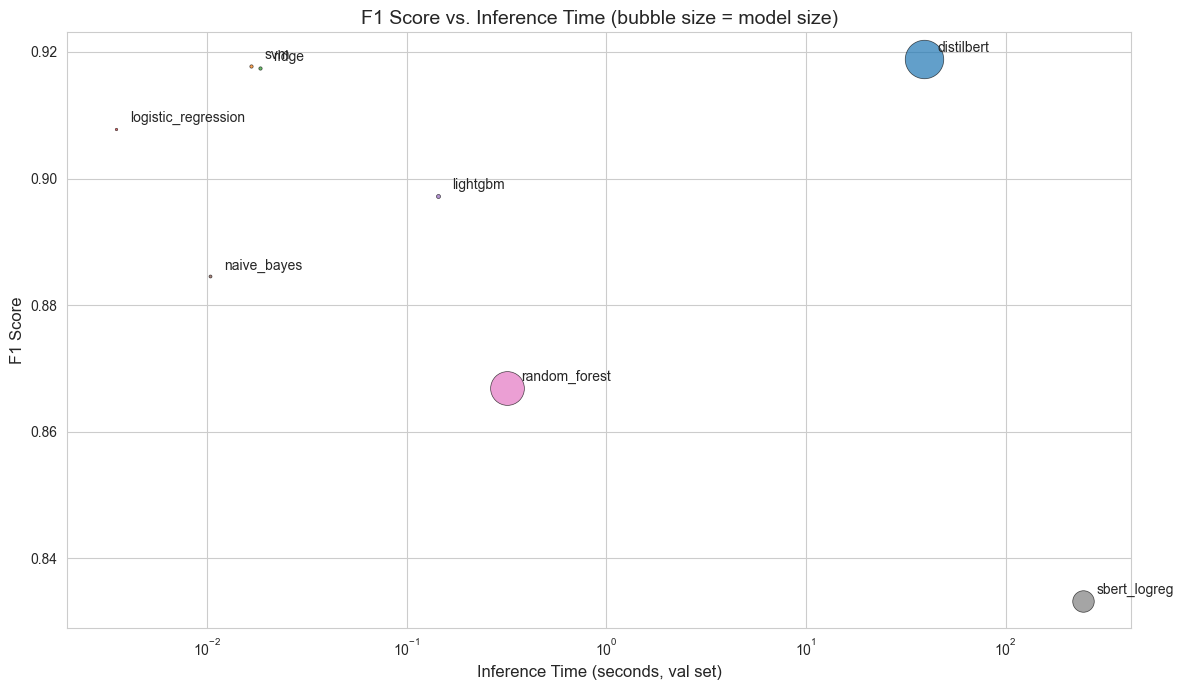

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

# Bubble chart: x=inference time, y=F1, size=model size
scatter_sizes = all_results['model_size_mb'].replace(0, 80).values
scatter_sizes = np.clip(scatter_sizes, 1, None)  # min size for visibility

for i, row in all_results.iterrows():
    size = max(row['model_size_mb'], 80) if row['model'] == 'sbert_logreg' else max(row['model_size_mb'], 1)
    ax.scatter(row['inference_time_sec'], row['f1'],
               s=size * 3, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.annotate(row['model'], (row['inference_time_sec'], row['f1']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

ax.set_xlabel('Inference Time (seconds, val set)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Inference Time (bubble size = model size)', fontsize=14)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 5. Confusion Matrices (Top 3 Models)

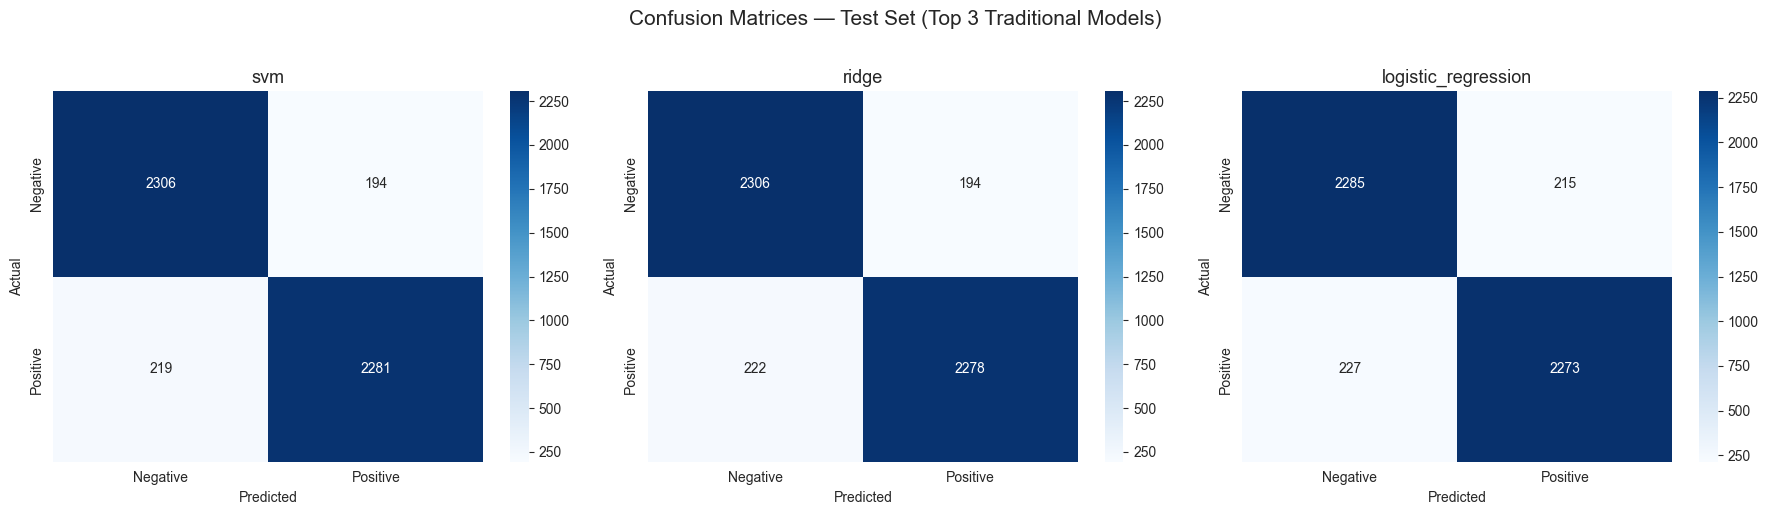

In [6]:
# Load test data and vectorizer for traditional models
test_data = joblib.load(MODELS_DIR / 'test_data.joblib')
X_test_tfidf = joblib.load(MODELS_DIR / 'X_test_tfidf.joblib')
y_test = np.array(test_data['y_test'])
X_test_text = test_data['X_test']

# Top 3 traditional models
top_models = ['svm', 'ridge', 'logistic_regression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_models):
    model = joblib.load(MODELS_DIR / f'{model_name}.joblib')
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'{model_name}', fontsize=13)
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set (Top 3 Traditional Models)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. ROC Curves

D:\code\Macromill\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


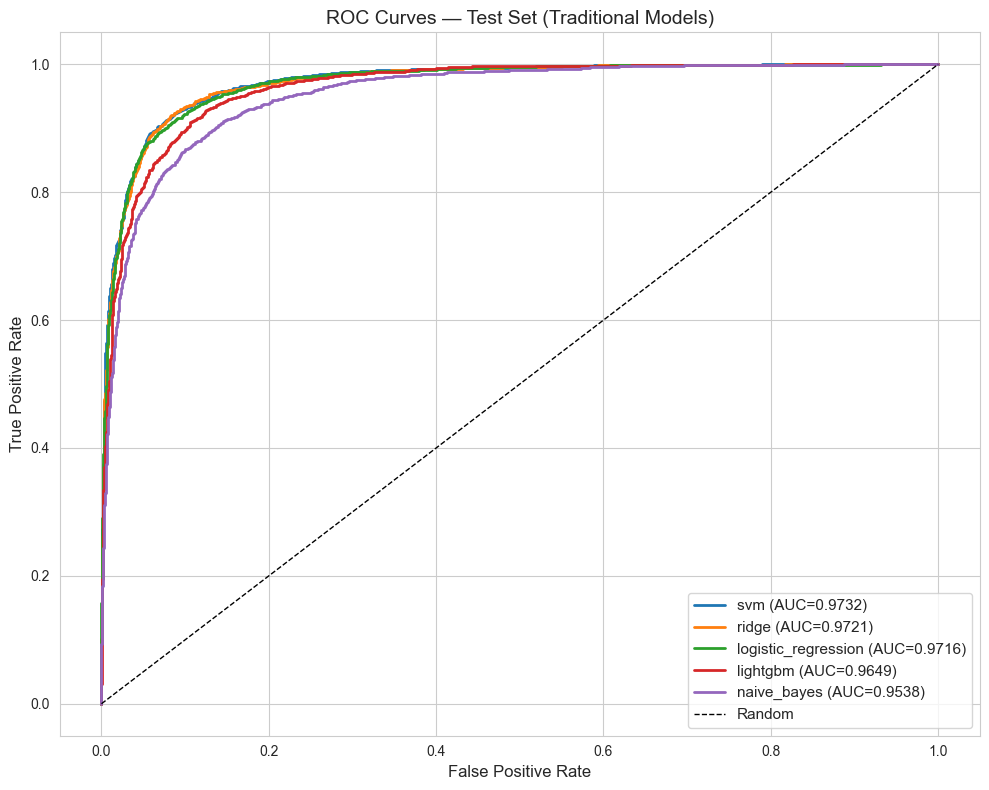

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

for model_name in ['svm', 'ridge', 'logistic_regression', 'lightgbm', 'naive_bayes']:
    model = joblib.load(MODELS_DIR / f'{model_name}.joblib')
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set (Traditional Models)', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7. Error Analysis (Best Traditional Model: SVM)

In [8]:
svm_model = joblib.load(MODELS_DIR / 'svm.joblib')
y_pred_svm = svm_model.predict(X_test_tfidf)
y_proba_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

# Find misclassified examples
misclassified = np.where(y_pred_svm != y_test)[0]
print(f'Misclassified: {len(misclassified)} / {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)')

# Show some misclassified examples with confidence
print(f'\n{"="*80}')
print('Sample Misclassified Reviews (SVM):')
print(f'{"="*80}')

np.random.seed(42)
sample_indices = np.random.choice(misclassified, min(8, len(misclassified)), replace=False)

for idx in sample_indices:
    actual = 'positive' if y_test[idx] == 1 else 'negative'
    predicted = 'positive' if y_pred_svm[idx] == 1 else 'negative'
    conf = y_proba_svm[idx] if y_pred_svm[idx] == 1 else 1 - y_proba_svm[idx]
    review = X_test_text[idx][:200]
    print(f'\nActual: {actual} | Predicted: {predicted} | Confidence: {conf:.3f}')
    print(f'Review: {review}...')
    print('-' * 60)

Misclassified: 413 / 5000 (8.3%)

Sample Misclassified Reviews (SVM):

Actual: positive | Predicted: negative | Confidence: 0.668
Review: dislike this movie and everyone would understand why the plot is poor so is the acting but in my opinion it is better than halloween although even this does not give many surprising moments a few scen...
------------------------------------------------------------

Actual: negative | Predicted: positive | Confidence: 0.550
Review: jack lemmon was one of our great actors his performances in days of wine and roses the apartment some like it hot missing to name the first ones that come to mind were all worthy of best actor nominat...
------------------------------------------------------------

Actual: negative | Predicted: positive | Confidence: 0.517
Review: michael rooker is a decent actor but he has no business being the lead except in a low budget movie he really does not have much charisma ryo ishibashi has a lot more screen presence and sadly he 

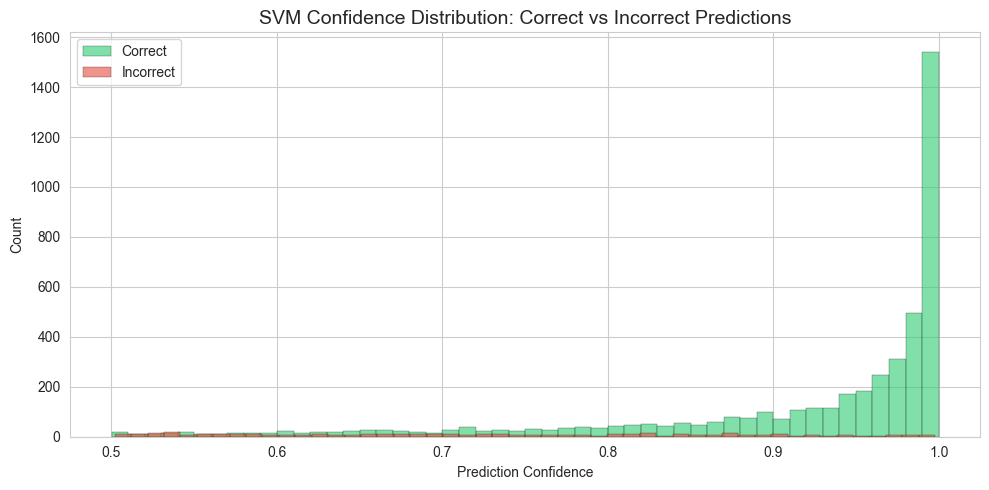

Mean confidence (correct): 0.9198
Mean confidence (incorrect): 0.7223


In [9]:
# Analyze confidence distribution of correct vs incorrect predictions
correct_mask = y_pred_svm == y_test
confidence = np.where(y_pred_svm == 1, y_proba_svm, 1 - y_proba_svm)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(confidence[correct_mask], bins=50, alpha=0.6, label='Correct', color='#2ecc71', edgecolor='black', linewidth=0.3)
ax.hist(confidence[~correct_mask], bins=50, alpha=0.6, label='Incorrect', color='#e74c3c', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Prediction Confidence')
ax.set_ylabel('Count')
ax.set_title('SVM Confidence Distribution: Correct vs Incorrect Predictions', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean confidence (correct): {confidence[correct_mask].mean():.4f}')
print(f'Mean confidence (incorrect): {confidence[~correct_mask].mean():.4f}')

## 8. DistilBERT Training History

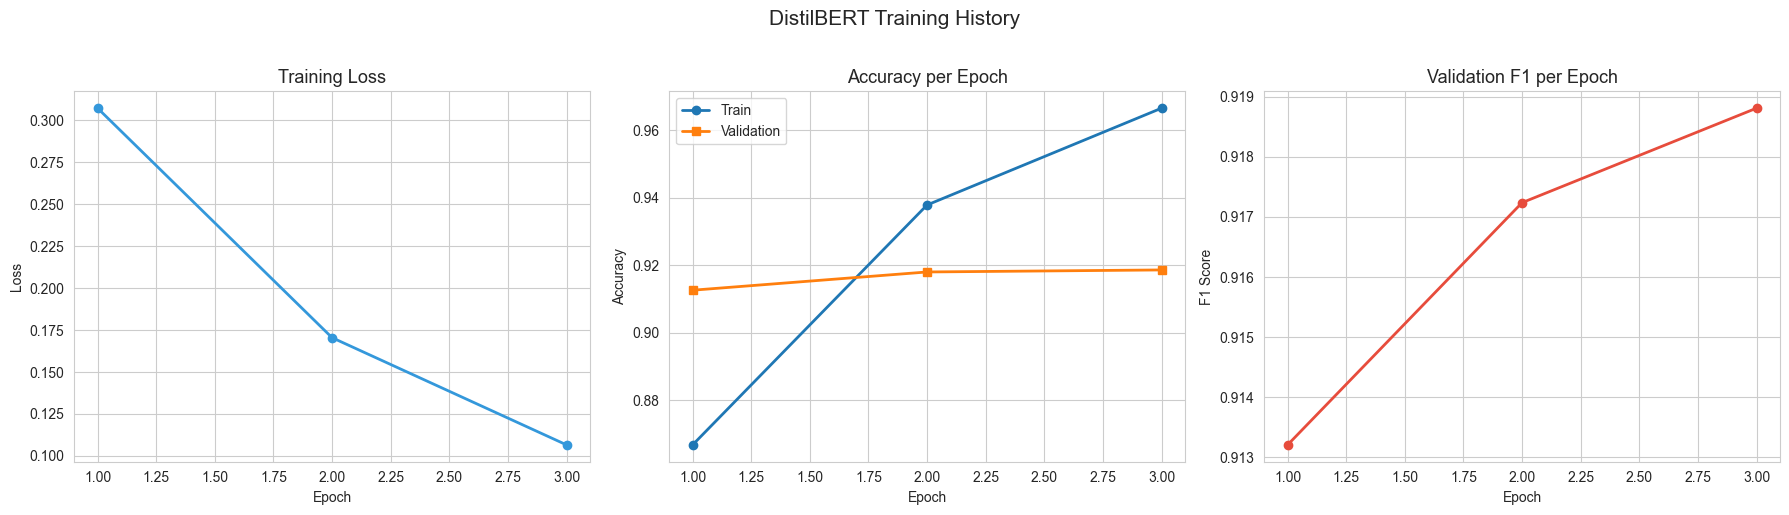

In [10]:
history = transformer['history']
epochs = [h['epoch'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
axes[0].plot(epochs, [h['train_loss'] for h in history], 'o-', color='#3498db', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontsize=13)

# Training vs validation accuracy
axes[1].plot(epochs, [h['train_acc'] for h in history], 'o-', label='Train', linewidth=2)
axes[1].plot(epochs, [h['val_accuracy'] for h in history], 's-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per Epoch', fontsize=13)
axes[1].legend()

# Validation F1
axes[2].plot(epochs, [h['val_f1'] for h in history], 'o-', color='#e74c3c', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1 per Epoch', fontsize=13)

plt.suptitle('DistilBERT Training History', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 9. Final Model Selection

### Summary

| Rank | Model | F1 | ROC-AUC | Train Time | Size | Notes |
|------|-------|-----|---------|------------|------|-------|
| 1 | DistilBERT | 0.9188 | 0.9754 | 2910s (GPU) | 256 MB | Best accuracy, but large and slow |
| 2 | SVM (LinearSVC) | 0.9178 | 0.9731 | 3.5s | 1.9 MB | Near-identical accuracy, 130x smaller |
| 3 | Ridge | 0.9175 | 0.9727 | 5.2s | 1.9 MB | Very close to SVM |
| 4 | Logistic Regression | 0.9078 | 0.9703 | 1.3s | 0.4 MB | Smallest model, still strong |
| 5 | LightGBM | 0.8973 | 0.9628 | 190.7s | 2.8 MB | Gradient boosting, moderate |
| 6 | Naive Bayes | 0.8845 | 0.9528 | 0.1s | 1.5 MB | Fastest training |
| 7 | Random Forest | 0.8669 | 0.9396 | 96.1s | 197 MB | Large, slow, weakest |
| 8 | SBERT + LogReg | 0.8332 | 0.9119 | 2157s | ~80 MB | Embeddings didn't help here |

### Decision: SVM (LinearSVC) for API deployment

**Rationale:**
- Only 0.1% F1 behind DistilBERT (0.9178 vs 0.9188) — statistically negligible
- 130x smaller model size (1.9 MB vs 256 MB) — dramatically smaller Docker image
- 2300x faster inference on the validation set
- No GPU required at inference time
- Simpler deployment: single joblib file + TF-IDF vectorizer

DistilBERT is the stronger model for applications where accuracy is paramount and resources are available.
For a containerized REST API, SVM provides the best accuracy-to-efficiency trade-off.

### Note on SBERT + LogReg

The sentence-transformer embeddings (all-MiniLM-L6-v2) underperformed TF-IDF on this task.
This is likely because:
1. The general-purpose embeddings are not optimized for sentiment
2. IMDb reviews are long (~231 words avg), and mean-pooled embeddings lose discriminative detail
3. TF-IDF with bigrams captures sentiment-specific phrases ("waste of time", "highly recommend") directly

A domain-specific sentence-transformer or SetFit fine-tuning would likely close this gap.

In [11]:
print('Final model for API deployment: SVM (LinearSVC) with TF-IDF features')
print(f'Validation F1: 0.9178 | Model size: 1.9 MB + 2.3 MB vectorizer')
print('\nPhase 3 evaluation complete.')

Final model for API deployment: SVM (LinearSVC) with TF-IDF features
Validation F1: 0.9178 | Model size: 1.9 MB + 2.3 MB vectorizer

Phase 3 evaluation complete.
